# 🏀 NBA Salary Predictor — Previsão de Salários da NBA

## Problema de Negócio
Com base nas estatísticas de desempenho da temporada 2022-23, este modelo
prevê o salário anual de um jogador da NBA.

Isso é útil para:
- Times que precisam tomar decisões estratégicas de contratação
- Agentes esportivos que negociam contratos com base em desempenho real
- Análise de jogadores sub ou supervalorizados no mercado

## Variável Alvo
`Salary` — salário anual do jogador em dólares (valor numérico contínuo)

## Dataset
NBA Players Stats and Salaries — Temporada 2022-23
- 467 registros
- 52 colunas
- Fonte: Kaggle

In [16]:
# ============================================================
# NBA Salary Predictor
# Célula 1: Importação das bibliotecas
# ============================================================

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Versionamento do modelo
import joblib
import json
import os
from datetime import datetime

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Ignorar warnings desnecessários
import warnings
warnings.filterwarnings("ignore")

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [17]:
# ============================================================
# Célula 2: Fase 1 — Carregar o Dataset
# ============================================================

# Carregando o dataset do NBA 2022-23
df = pd.read_csv("nba_2022-23_all_stats_with_salary.csv")

print(f"✅ Dataset carregado com sucesso!")
print(f"   Linhas    : {df.shape[0]}")
print(f"   Colunas   : {df.shape[1]}")
print(f"\n📋 Primeiros registros:")
print(df.head())

✅ Dataset carregado com sucesso!
   Linhas    : 467
   Colunas   : 52

📋 Primeiros registros:
   Unnamed: 0        Player Name    Salary Position  Age     Team  GP  GS  \
0           0      Stephen Curry  48070014       PG   34      GSW  56  56   
1           1          John Wall  47345760       PG   32      LAC  34   3   
2           2  Russell Westbrook  47080179       PG   34  LAL/LAC  73  24   
3           3       LeBron James  44474988       PF   38      LAL  55  54   
4           4       Kevin Durant  44119845       PF   34  BRK/PHO  47  47   

     MP    FG  ...  TOV%  USG%  OWS  DWS   WS  WS/48  OBPM  DBPM  BPM  VORP  
0  34.7  10.0  ...  12.5  31.0  5.8  2.0  7.8  0.192   7.5   0.1  7.5   4.7  
1  22.2   4.1  ...  17.1  27.0 -0.4  0.7  0.3  0.020  -0.8  -0.4 -1.2   0.1  
2  29.1   5.9  ...  18.4  27.7 -0.6  2.6  1.9  0.044   0.3  -0.1  0.2   1.2  
3  35.5  11.1  ...  11.6  33.3  3.2  2.4  5.6  0.138   5.5   0.6  6.1   4.0  
4  35.6  10.3  ...  13.4  30.7  4.7  2.1  6.8  0.194 

In [18]:
# ============================================================
# Célula 3: Fase 1 — Inspeção Inicial do Dataset
# ============================================================

print("=== INFORMAÇÕES GERAIS DO DATASET ===")
print("-" * 45)
print(f"  Dimensões        : {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"  Memória utilizada: {df.memory_usage().sum() / 1024:.2f} KB")
print("-" * 45)

print("\n=== TIPOS DE DADOS POR COLUNA ===")
print("-" * 45)
print(df.dtypes)
print("-" * 45)

print("\n=== VALORES NULOS POR COLUNA ===")
print("-" * 45)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({
    "Nulos"      : nulos,
    "Percentual" : nulos_pct.round(2)
})
# Mostrar apenas colunas que têm nulos
print(nulos_df[nulos_df["Nulos"] > 0])
print("-" * 45)

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df.describe().round(2))

=== INFORMAÇÕES GERAIS DO DATASET ===
---------------------------------------------
  Dimensões        : 467 linhas x 52 colunas
  Memória utilizada: 189.85 KB
---------------------------------------------

=== TIPOS DE DADOS POR COLUNA ===
---------------------------------------------
Unnamed: 0         int64
Player Name       object
Salary             int64
Position          object
Age                int64
Team              object
GP                 int64
GS                 int64
MP               float64
FG               float64
FGA              float64
FG%              float64
3P               float64
3PA              float64
3P%              float64
2P               float64
2PA              float64
2P%              float64
eFG%             float64
FT               float64
FTA              float64
FT%              float64
ORB              float64
DRB              float64
TRB              float64
AST              float64
STL              float64
BLK              float64
TOV          

## Fase 1: Análise Exploratória de Dados (EDA)

Nesta fase analisamos visualmente o dataset para entender:
- A distribuição da variável alvo (Salary)
- A relação entre as variáveis explicativas e o salário
- A correlação entre as variáveis numéricas

Esses achados orientarão nossas decisões de limpeza e modelagem.

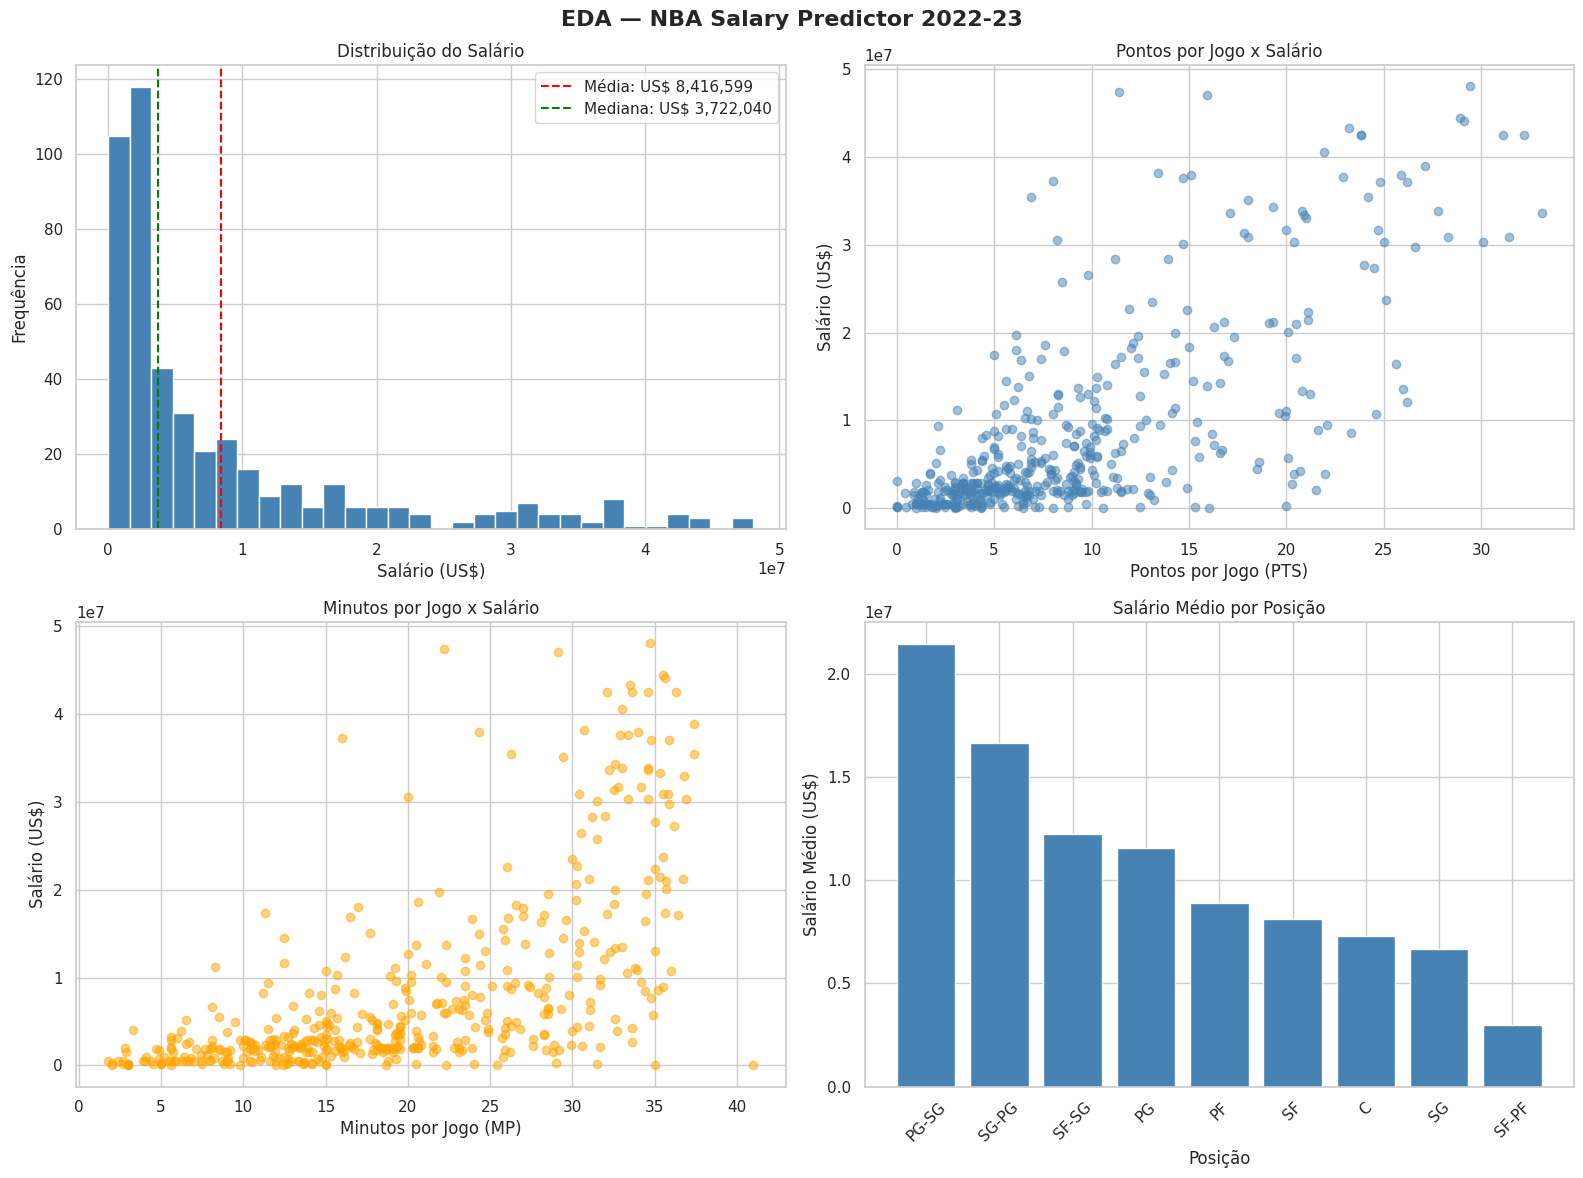

✅ Gráficos EDA gerados!


In [19]:
# ============================================================
# Célula 4: Fase 1 — Visualizações EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA — NBA Salary Predictor 2022-23", fontsize=16, fontweight="bold")

# --------------------------------------------------------
# Gráfico 1: Distribuição do Salário (variável alvo)
# Mostra se a distribuição é simétrica ou assimétrica
# --------------------------------------------------------
axes[0, 0].hist(df["Salary"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribuição do Salário")
axes[0, 0].set_xlabel("Salário (US$)")
axes[0, 0].set_ylabel("Frequência")
axes[0, 0].axvline(df["Salary"].mean(), color="red", linestyle="--", label=f'Média: US$ {df["Salary"].mean():,.0f}')
axes[0, 0].axvline(df["Salary"].median(), color="green", linestyle="--", label=f'Mediana: US$ {df["Salary"].median():,.0f}')
axes[0, 0].legend()

# --------------------------------------------------------
# Gráfico 2: Dispersão PTS x Salary
# Mostra se jogadores que pontuam mais ganham mais
# --------------------------------------------------------
axes[0, 1].scatter(df["PTS"], df["Salary"], alpha=0.5, color="steelblue")
axes[0, 1].set_title("Pontos por Jogo x Salário")
axes[0, 1].set_xlabel("Pontos por Jogo (PTS)")
axes[0, 1].set_ylabel("Salário (US$)")

# --------------------------------------------------------
# Gráfico 3: Dispersão MP x Salary
# Mostra se jogadores que jogam mais minutos ganham mais
# --------------------------------------------------------
axes[1, 0].scatter(df["MP"], df["Salary"], alpha=0.5, color="orange")
axes[1, 0].set_title("Minutos por Jogo x Salário")
axes[1, 0].set_xlabel("Minutos por Jogo (MP)")
axes[1, 0].set_ylabel("Salário (US$)")

# --------------------------------------------------------
# Gráfico 4: Salário médio por posição
# Mostra qual posição tem maior remuneração
# --------------------------------------------------------
salary_position = df.groupby("Position")["Salary"].mean().sort_values(ascending=False)
axes[1, 1].bar(salary_position.index, salary_position.values, color="steelblue", edgecolor="white")
axes[1, 1].set_title("Salário Médio por Posição")
axes[1, 1].set_xlabel("Posição")
axes[1, 1].set_ylabel("Salário Médio (US$)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("grafico_eda.png", dpi=120)
plt.show()
plt.close()
print("✅ Gráficos EDA gerados!")

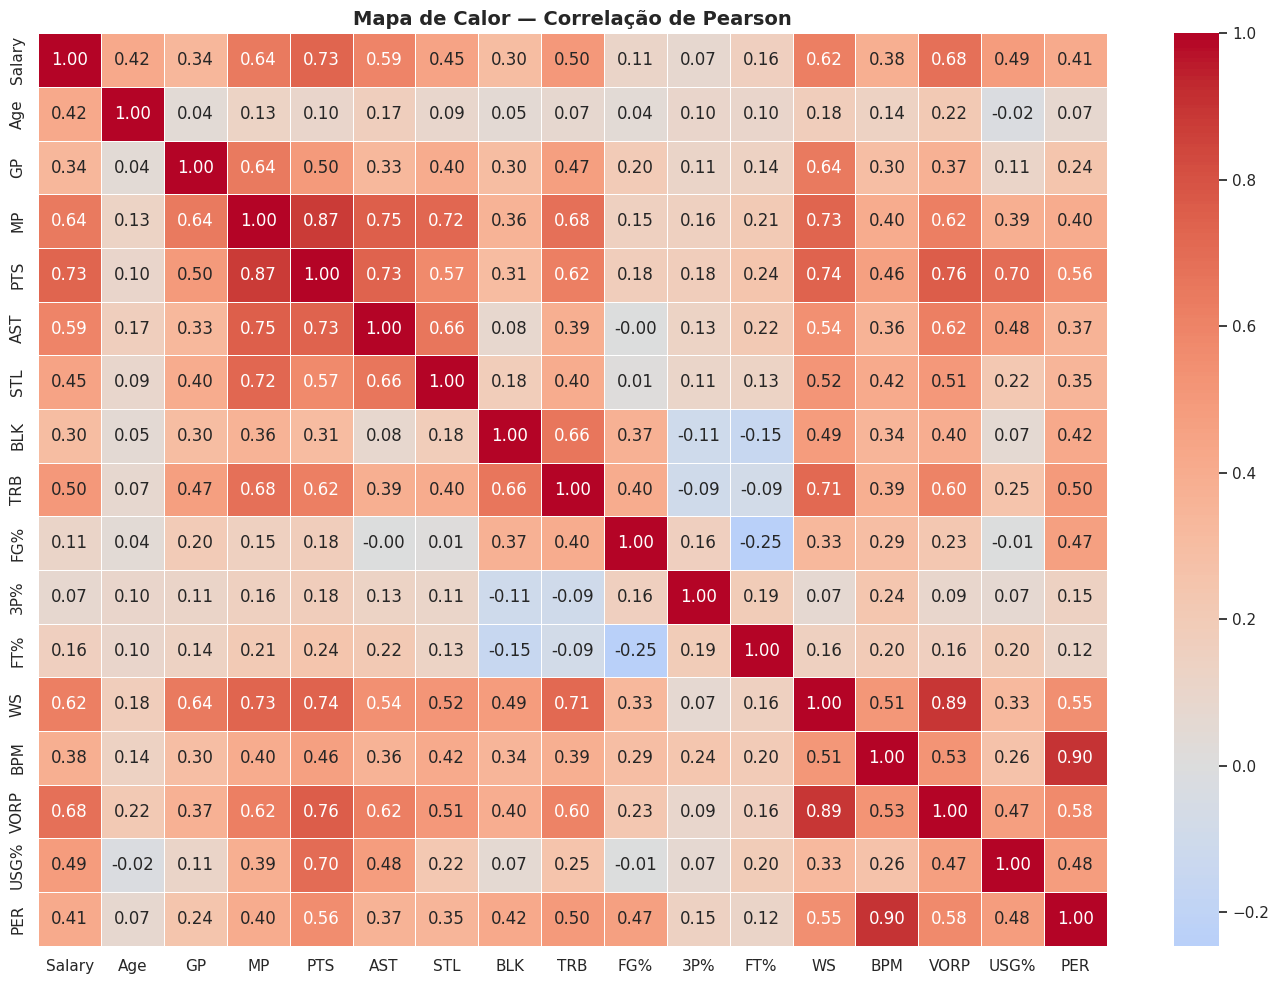

✅ Mapa de calor gerado!


In [20]:
# ============================================================
# Célula 5: Fase 1 — Mapa de Calor de Correlação
# ============================================================

# Selecionando as colunas mais relevantes para análise
# Evitamos colunas redundantes e focamos nas principais métricas
colunas_relevantes = [
    "Salary", "Age", "GP", "MP", "PTS", "AST",
    "STL", "BLK", "TRB", "FG%", "3P%", "FT%",
    "WS", "BPM", "VORP", "USG%", "PER"
]

# Calculando a correlação de Pearson entre as variáveis
correlacao = df[colunas_relevantes].corr()

# Plotando o mapa de calor
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlacao,
    annot=True,          # mostra os valores dentro das células
    fmt=".2f",           # formato com 2 casas decimais
    cmap="coolwarm",     # azul = correlação negativa, vermelho = positiva
    center=0,            # centro da escala de cores no zero
    linewidths=0.5,      # linhas entre as células
    ax=ax
)
ax.set_title("Mapa de Calor — Correlação de Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico_correlacao.png", dpi=120)
plt.show()
plt.close()
print("✅ Mapa de calor gerado!")

## Análise Textual — Achados da EDA

### Distribuição da variável alvo (Salary)
O salário apresenta distribuição fortemente assimétrica à direita,
com a maioria dos jogadores ganhando entre US$ 1M e US$ 5M e poucos
jogadores com salários acima de US$ 30M. A média (US$ 8,4M) está bem
acima da mediana (US$ 3,7M), confirmando a assimetria. Isso indica
que usaremos a **mediana** como estratégia de imputação de valores
ausentes nas etapas seguintes.

### Variáveis mais relevantes
As variáveis com maior correlação com o salário são PTS (0.73),
VORP (0.68), MP (0.64) e WS (0.62), indicando que jogadores que
pontuam mais, jogam mais minutos e contribuem mais para as vitórias
tendem a ser mais bem remunerados.

### Multicolinearidade
Detectamos alta correlação entre MP e PTS (0.87), WS e VORP (0.89)
e BPM e PER (0.90). Na Fase 4 avaliaremos quais variáveis remover
para evitar que a multicolinearidade distorça o modelo de regressão.

### Posições
O dataset apresenta posições combinadas como PG-SG e SF-SG que
precisarão ser simplificadas na Fase 2.

### Orientação para modelagem
Dado o perfil assimétrico do salário, consideraremos aplicar
transformação logarítmica na variável alvo para melhorar o
desempenho do modelo de regressão linear.

## Fase 2: Tratamento e Limpeza (Data Prep)

Nesta fase tratamos os problemas encontrados na EDA:
- Remoção de colunas desnecessárias
- Simplificação das posições combinadas
- Tratamento de valores ausentes
- Detecção e tratamento de outliers

In [22]:
# ============================================================
# Célula 6: Fase 2 — Limpeza Inicial
# ============================================================

# Criando uma cópia do dataset original para não alterá-lo
df_limpo = df.copy()

# --------------------------------------------------------
# Passo 1: Remover colunas desnecessárias
# --------------------------------------------------------
colunas_remover = [
    # Identificação — não são variáveis preditoras
    "Player Name", "Team", "Unnamed: 0",

    # Baixa correlação com salário (abaixo de 0.20)
    "FG%", "3P%", "FT%", "2P%", "eFG%",

    # Tentativas de arremesso — redundantes com as convertidas
    "FGA", "3PA", "FTA", "2PA",

    # Métricas redundantes
    "BPM",          # correlação 0.90 com PER — mantemos PER
    "WS/48",        # versão normalizada de WS — mantemos WS
    "OBPM",         # componente de BPM
    "DBPM",         # componente de BPM
    "ORB",          # componente de TRB — mantemos TRB
    "DRB",          # componente de TRB — mantemos TRB
    "Total Minutes" # redundante com MP * GP
]

df_limpo = df_limpo.drop(columns=colunas_remover)
print(f"✅ {len(colunas_remover)} colunas removidas")
print(f"   Colunas restantes: {len(df_limpo.columns)}")

# --------------------------------------------------------
# Passo 2: Simplificar posições combinadas
# Jogadores com posições como 'PG-SG' serão classificados
# pela primeira posição informada
# --------------------------------------------------------
df_limpo["Position"] = df_limpo["Position"].apply(
    lambda x: x.split("-")[0] if "-" in str(x) else x
)
print(f"\n✅ Posições simplificadas:")
print(df_limpo["Position"].value_counts())

# --------------------------------------------------------
# Passo 3: Verificar e remover duplicatas
# --------------------------------------------------------
n_duplicatas = df_limpo.duplicated().sum()
print(f"\n✅ Duplicatas encontradas: {n_duplicatas}")
if n_duplicatas > 0:
    df_limpo = df_limpo.drop_duplicates()
    print(f"   Duplicatas removidas!")

print(f"\n📊 Shape após limpeza inicial: {df_limpo.shape}")
print(f"\n📋 Colunas mantidas:")
for col in df_limpo.columns:
    print(f"   ✅ {col}")

✅ 19 colunas removidas
   Colunas restantes: 33

✅ Posições simplificadas:
Position
SG    117
SF     94
C      91
PF     86
PG     79
Name: count, dtype: int64

✅ Duplicatas encontradas: 0

📊 Shape após limpeza inicial: (467, 33)

📋 Colunas mantidas:
   ✅ Salary
   ✅ Position
   ✅ Age
   ✅ GP
   ✅ GS
   ✅ MP
   ✅ FG
   ✅ 3P
   ✅ 2P
   ✅ FT
   ✅ TRB
   ✅ AST
   ✅ STL
   ✅ BLK
   ✅ TOV
   ✅ PF
   ✅ PTS
   ✅ PER
   ✅ TS%
   ✅ 3PAr
   ✅ FTr
   ✅ ORB%
   ✅ DRB%
   ✅ TRB%
   ✅ AST%
   ✅ STL%
   ✅ BLK%
   ✅ TOV%
   ✅ USG%
   ✅ OWS
   ✅ DWS
   ✅ WS
   ✅ VORP


### Decisões de Limpeza Inicial

**Colunas removidas (19 no total):**
- `Unnamed: 0` e `Player Name` e `Team`: não são variáveis preditoras
- `FG%`, `3P%`, `FT%`, `2P%`, `eFG%`: correlação menor que 0.20 com o salário
- `FGA`, `3PA`, `FTA`, `2PA`: tentativas de arremesso, redundantes com as convertidas
- `BPM`, `OBPM`, `DBPM`: redundantes com PER (correlação 0.90)
- `WS/48`: versão normalizada de WS, redundante
- `ORB`, `DRB`: componentes de TRB, redundantes
- `Total Minutes`: redundante com MP × GP

**Posições simplificadas:**
Jogadores com posições combinadas como PG-SG foram classificados
pela primeira posição informada, resultando em 5 posições limpas:
PG, SG, SF, PF e C.

**Duplicatas:**
Nenhuma duplicata encontrada no dataset.



In [23]:
# ============================================================
# Célula 7: Fase 2 — Tratamento de Valores Ausentes
# ============================================================

# Verificando valores ausentes antes do tratamento
print("=== VALORES AUSENTES ANTES DO TRATAMENTO ===")
print("-" * 45)
nulos = df_limpo.isnull().sum()
nulos = nulos[nulos > 0]
for col, n in nulos.items():
    pct = (n / len(df_limpo)) * 100
    print(f"  {col:<10}: {n} nulos ({pct:.1f}%)")
print("-" * 45)

# Imputação pela mediana
# Justificativa: distribuição assimétrica do salário torna
# a mediana mais robusta que a média para imputação
colunas_com_nulos = df_limpo.columns[df_limpo.isnull().any()].tolist()
for col in colunas_com_nulos:
    mediana = df_limpo[col].median()
    df_limpo[col] = df_limpo[col].fillna(mediana)
    print(f"✅ {col:<10}: substituído pela mediana ({mediana:.2f})")

# Verificando após o tratamento
print("\n=== VALORES AUSENTES APÓS O TRATAMENTO ===")
print("-" * 45)
nulos_depois = df_limpo.isnull().sum().sum()
print(f"  Total de nulos restantes: {nulos_depois}")
print("-" * 45)

=== VALORES AUSENTES ANTES DO TRATAMENTO ===
---------------------------------------------
  TS%       : 1 nulos (0.2%)
  3PAr      : 1 nulos (0.2%)
  FTr       : 1 nulos (0.2%)
---------------------------------------------
✅ TS%       : substituído pela mediana (0.57)
✅ 3PAr      : substituído pela mediana (0.41)
✅ FTr       : substituído pela mediana (0.23)

=== VALORES AUSENTES APÓS O TRATAMENTO ===
---------------------------------------------
  Total de nulos restantes: 0
---------------------------------------------


### Tratamento de Outliers

Detectamos outliers nas variáveis numéricas usando boxplots.
Para o salário especificamente, optamos por MANTER os outliers
pois superestrelas como LeBron James e Stephen Curry representam
casos reais e legítimos do mercado da NBA — removê-los distorceria
a análise de negócio.

Para as variáveis explicativas, aplicamos contenção por limite
(winsorização) nas colunas com outliers extremos, substituindo
valores fora dos limites pelo valor do limite mais próximo.

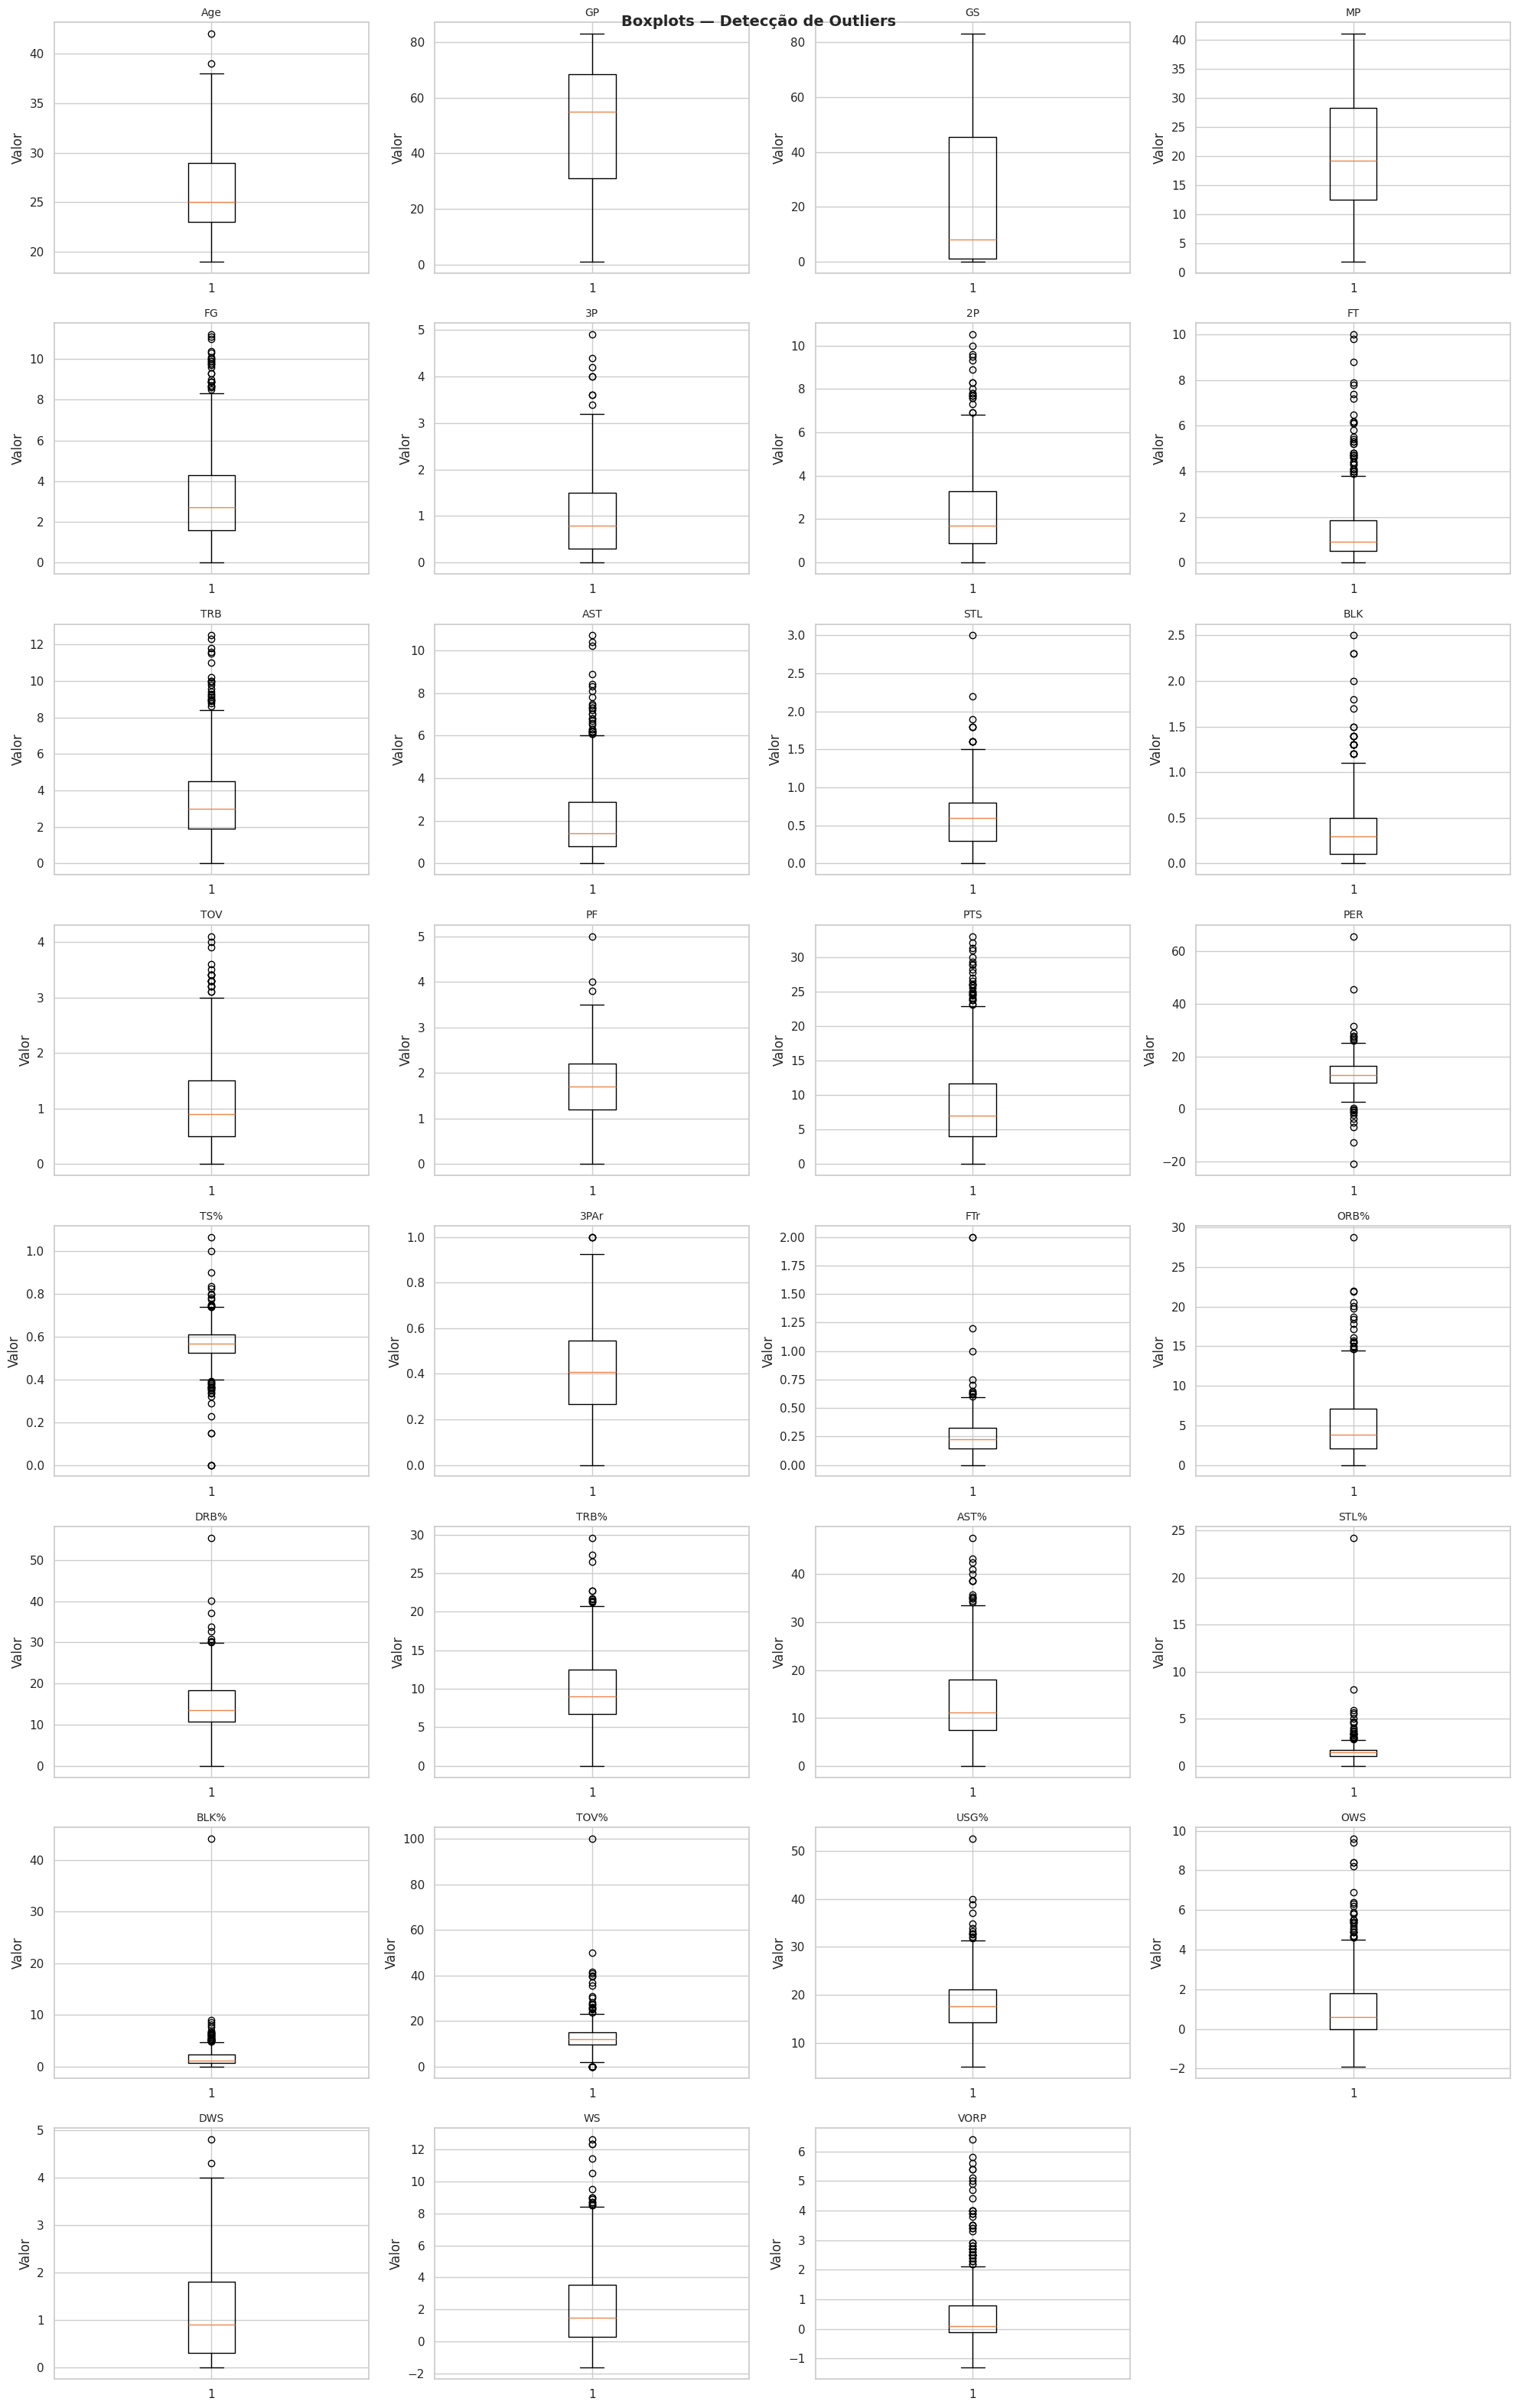

✅ Boxplots gerados!

=== OUTLIERS TRATADOS POR WINSORIZAÇÃO ===
---------------------------------------------
  Age         : 2 outliers contidos
  FG          : 26 outliers contidos
  3P          : 8 outliers contidos
  2P          : 19 outliers contidos
  FT          : 41 outliers contidos
  TRB         : 22 outliers contidos
  AST         : 30 outliers contidos
  STL         : 10 outliers contidos
  BLK         : 22 outliers contidos
  TOV         : 19 outliers contidos
  PF          : 3 outliers contidos
  PTS         : 29 outliers contidos
  PER         : 20 outliers contidos
  TS%         : 36 outliers contidos
  3PAr        : 3 outliers contidos
  FTr         : 12 outliers contidos
  ORB%        : 19 outliers contidos
  DRB%        : 9 outliers contidos
  TRB%        : 10 outliers contidos
  AST%        : 15 outliers contidos
  STL%        : 26 outliers contidos
  BLK%        : 32 outliers contidos
  TOV%        : 37 outliers contidos
  USG%        : 12 outliers contidos
  OWS  

In [24]:
# ============================================================
# Célula 8: Fase 2 — Detecção e Tratamento de Outliers
# ============================================================

# Selecionando apenas colunas numéricas para análise
# excluindo a variável alvo Salary e a categórica Position
colunas_numericas = df_limpo.select_dtypes(include="number").columns.tolist()
colunas_numericas.remove("Salary")

# --------------------------------------------------------
# Visualização dos outliers com boxplots
# --------------------------------------------------------
n_cols = 4
n_rows = (len(colunas_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].boxplot(df_limpo[col].dropna())
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Valor")

# Remover eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots — Detecção de Outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico_boxplots.png", dpi=120)
plt.show()
plt.close()
print("✅ Boxplots gerados!")

# --------------------------------------------------------
# Tratamento de outliers por winsorização (IQR)
# Substituímos valores extremos pelo limite mais próximo
# em vez de removê-los — preservamos todos os registros
# --------------------------------------------------------
def winsorizacao(df, colunas, fator=1.5):
    """
    Aplica winsorização nas colunas informadas:
    valores abaixo do limite inferior são substituídos
    pelo limite inferior, e valores acima do limite
    superior são substituídos pelo limite superior.
    """
    df = df.copy()
    relatorio = {}
    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        if n_out > 0:
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)
            relatorio[col] = int(n_out)
    return df, relatorio

# Aplicando winsorização nas variáveis explicativas
df_limpo, relatorio_outliers = winsorizacao(df_limpo, colunas_numericas)

# Relatório
print("\n=== OUTLIERS TRATADOS POR WINSORIZAÇÃO ===")
print("-" * 45)
for col, n in relatorio_outliers.items():
    print(f"  {col:<12}: {n} outliers contidos")
print("-" * 45)
print(f"\n📊 Shape final após Data Prep: {df_limpo.shape}")

In [25]:
# ============================================================
# Salvando o dataset limpo
# ============================================================

import os
os.makedirs("data/processed", exist_ok=True)
df_limpo.to_csv("data/processed/nba_limpo.csv", index=False)
print("✅ Dataset limpo salvo em data/processed/nba_limpo.csv")
print(f"   Shape final: {df_limpo.shape}")

✅ Dataset limpo salvo em data/processed/nba_limpo.csv
   Shape final: (467, 33)
